# Keep Working — Pomodoro Template

A Jupyter notebook implementing a Pomodoro-style productivity tool called "Keep Working" with timer logic, persistence, notifications, visualizations, VS Code integration examples, and unit tests.

Created: 2026-06-01


In [ ]:
# Standard library
import sys
import os
import time
import asyncio
import json
import sqlite3
import datetime
from dataclasses import dataclass, asdict
from pathlib import Path
import logging

logging.basicConfig(level=logging.INFO)

# Data & plotting
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Jupyter widgets (optional)
try:
    import ipywidgets as widgets
    from IPython.display import display
except Exception:
    widgets = None

# Desktop notifications (optional)
try:
    from plyer import notification as _plyer_notification
except Exception:
    _plyer_notification = None

print("imports ready")

imports ready


In [ ]:
## Section 2 — Configuration
# Use the launcher module as single source of truth for settings.
# Falls back to a self-contained implementation if the module is missing.

_NB_DIR = Path("notebooks")
if str(_NB_DIR.resolve()) not in sys.path:
    sys.path.insert(0, str(_NB_DIR.resolve()))

try:
    from keep_working_launcher import (
        CONFIG_PATH,
        DEFAULT_SETTINGS,
        load_config,
        save_config,
    )
except Exception:
    CONFIG_PATH = _NB_DIR / "keep_working_config.json"
    DEFAULT_SETTINGS = {
        "task": "Unnamed",
        "work": 25 * 60,
        "short": 5 * 60,
        "long": 15 * 60,
        "cycles_per_long": 4,
        "notify": False,
        "sound": False,
        "repeat": False,
        "status_file": str(_NB_DIR / "keep_working_status.json"),
    }

    def load_config(path=CONFIG_PATH):
        path = Path(path)
        if path.exists():
            try:
                data = json.loads(path.read_text())
            except Exception:
                data = None
            if isinstance(data, dict):
                return {k: data.get(k, d) for k, d in DEFAULT_SETTINGS.items()}
        return dict(DEFAULT_SETTINGS)

    def save_config(settings, path=CONFIG_PATH):
        path = Path(path)
        path.parent.mkdir(parents=True, exist_ok=True)
        cleaned = {k: (settings or {}).get(k, d) for k, d in DEFAULT_SETTINGS.items()}
        path.write_text(json.dumps(cleaned, indent=2))
        return cleaned

# Load persisted settings (falls back to defaults on first run)
SETTINGS = load_config()

WORK_DURATION = SETTINGS["work"]
SHORT_BREAK = SETTINGS["short"]
LONG_BREAK = SETTINGS["long"]
CYCLES_PER_LONG_BREAK = SETTINGS["cycles_per_long"]

print("config loaded from", CONFIG_PATH)

defaults set


In [ ]:
# Session data model and persistence helpers

@dataclass
class SessionRecord:
    task_name: str
    start_ts: str
    end_ts: str
    duration_s: int
    kind: str  # 'work' | 'short_break' | 'long_break'

HISTORY_JSON = Path("notebooks") / "keep_working_history.json"
HISTORY_DB = Path("notebooks") / "keep_working_history.db"


def append_json_record(rec: SessionRecord, path=HISTORY_JSON):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    arr = []
    if path.exists():
        arr = json.loads(path.read_text())
    arr.append(asdict(rec))
    path.write_text(json.dumps(arr, indent=2))


def init_db(path=HISTORY_DB):
    conn = sqlite3.connect(str(path))
    conn.execute(
        """CREATE TABLE IF NOT EXISTS sessions(
            id INTEGER PRIMARY KEY,
            task_name TEXT,
            start_ts TEXT,
            end_ts TEXT,
            duration_s INTEGER,
            kind TEXT
        )"""
    )
    conn.commit()
    conn.close()


def append_db_record(rec: SessionRecord, path=HISTORY_DB):
    init_db(path)
    conn = sqlite3.connect(str(path))
    conn.execute(
        "INSERT INTO sessions(task_name, start_ts, end_ts, duration_s, kind) VALUES (?,?,?,?,?)",
        (rec.task_name, rec.start_ts, rec.end_ts, rec.duration_s, rec.kind),
    )
    conn.commit()
    conn.close()


print("persistence helpers ready")

persistence helpers ready


In [ ]:
# Notifications & sound alerts (must be defined before the async timer)

def send_notification(title, message):
    """Desktop notification via plyer, else print fallback."""
    if _plyer_notification:
        try:
            _plyer_notification.notify(title=title, message=message)
            return
        except Exception:
            pass
    print(f"notification: {title} — {message}")


def play_sound():
    """Simple terminal bell."""
    try:
        print("\a", end="", flush=True)
    except Exception:
        pass


print("notification helpers ready")

In [ ]:
# Synchronous Pomodoro timer (blocking, for scripting / CLI use)

class PomodoroTimer:
    def __init__(self, work=WORK_DURATION, short=SHORT_BREAK, long=LONG_BREAK,
                 cycles_per_long=CYCLES_PER_LONG_BREAK):
        self.work = work
        self.short = short
        self.long = long
        self.cycles_per_long = cycles_per_long
        self._running = False
        self._paused = False
        self._state = "idle"
        self._cycle_count = 0
        self._start_ts = None

    def start_work(self):
        self._state = "work"
        self._running = True
        self._paused = False
        self._start_ts = time.time()
        print("work started")

    def pause(self):
        if self._running and not self._paused:
            self._paused = True
            print("paused")

    def resume(self):
        if self._running and self._paused:
            self._paused = False
            print("resumed")

    def reset(self):
        self._running = False
        self._paused = False
        self._state = "idle"
        self._start_ts = None
        print("reset")


print("sync timer ready")

async timer UI wired


In [ ]:
# Async non-blocking timer with optional ipywidgets controls

class AsyncPomodoro:
    def __init__(self, work=WORK_DURATION, short=SHORT_BREAK, long=LONG_BREAK,
                 cycles_per_long=CYCLES_PER_LONG_BREAK):
        self.work = work
        self.short = short
        self.long = long
        self.cycles_per_long = cycles_per_long
        self._task = None
        self._cancel = False
        self.state = "idle"
        self.remaining = 0
        self.current_kind = None
        self._on_finish = None
        self.notify = False
        self.sound = False
        self.task_name = "Unnamed"

    async def _countdown(self, seconds, kind="work"):
        self.current_kind = kind
        self.remaining = seconds
        self.state = kind
        start = time.time()
        try:
            while self.remaining > 0 and not self._cancel:
                await asyncio.sleep(1)
                self.remaining = max(0, seconds - int(time.time() - start))
            if not self._cancel:
                if self._on_finish:
                    try:
                        self._on_finish(kind, seconds)
                    except Exception as exc:
                        print("on_finish error:", exc)
                if self.notify:
                    send_notification("Keep Working", f"{kind} finished")
                if self.sound:
                    play_sound()
        finally:
            self._cancel = False

    def start(self, loop, seconds=None, kind="work", on_finish=None):
        if seconds is None:
            seconds = self.work if kind == "work" else self.short
        self._cancel = False
        self._on_finish = on_finish
        self._task = loop.create_task(self._countdown(seconds, kind=kind))

    def stop(self):
        self._cancel = True
        if self._task:
            try:
                self._task.cancel()
            except Exception:
                pass

    def is_running(self):
        return self._task is not None and not self._task.done()


# --- Notebook wiring ---

async_pom = AsyncPomodoro()

try:
    loop = asyncio.get_running_loop()
except RuntimeError:
    loop = asyncio.new_event_loop()
    asyncio.set_event_loop(loop)


async def _updater(label_widget):
    """Refresh the label widget every second."""
    while True:
        try:
            if async_pom.current_kind:
                m, s = divmod(async_pom.remaining, 60)
                label_widget.value = f"{async_pom.current_kind}: {m:02d}:{s:02d}"
            else:
                label_widget.value = "Idle"
            await asyncio.sleep(1)
        except asyncio.CancelledError:
            break


def _on_finish(kind, duration_s=None):
    """Log a completed session to JSON + SQLite."""
    end = datetime.datetime.now(datetime.timezone.utc)
    if duration_s is None:
        duration_s = async_pom.work if kind == "work" else (
            async_pom.long if kind == "long_break" else async_pom.short
        )
    start = end - datetime.timedelta(seconds=duration_s)
    rec = SessionRecord(
        task_name=async_pom.task_name,
        start_ts=start.isoformat(),
        end_ts=end.isoformat(),
        duration_s=duration_s,
        kind=kind,
    )
    append_json_record(rec)
    append_db_record(rec)
    print("logged", kind)


if widgets:
    start_btn = widgets.Button(description="Start Work")
    pause_btn = widgets.Button(description="Stop")
    reset_btn = widgets.Button(description="Reset")
    skip_btn = widgets.Button(description="Skip")
    label = widgets.Label("Idle")
    box = widgets.HBox([start_btn, pause_btn, reset_btn, skip_btn, label])
    display(box)

    def on_start(b):
        if not async_pom.is_running():
            async_pom.start(loop, kind="work", on_finish=_on_finish)
            if not hasattr(on_start, "_updater_task") or on_start._updater_task.done():
                on_start._updater_task = loop.create_task(_updater(label))

    def on_stop(b):
        async_pom.stop()
        label.value = "Stopped"

    def on_reset(b):
        async_pom.stop()
        async_pom.current_kind = None
        async_pom.remaining = 0
        label.value = "Idle"

    def on_skip(b):
        async_pom.stop()
        async_pom.start(loop, seconds=async_pom.short, kind="short_break", on_finish=_on_finish)

    start_btn.on_click(on_start)
    pause_btn.on_click(on_stop)
    reset_btn.on_click(on_reset)
    skip_btn.on_click(on_skip)

print("async timer ready")

# Expose for other cells / manual use
__async_pom__ = async_pom
__async_loop__ = loop

notification helpers ready


In [ ]:
# Example: log a completed work session
_now = datetime.datetime.now(datetime.timezone.utc)
rec = SessionRecord(
    task_name="Example Task",
    start_ts=_now.isoformat(),
    end_ts=(_now + datetime.timedelta(minutes=25)).isoformat(),
    duration_s=25 * 60,
    kind="work",
)
append_json_record(rec)
append_db_record(rec)
print("sample record appended")

sample record appended


/tmp/ipykernel_102071/3464451783.py:4: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  rec = SessionRecord(task_name='Example Task', start_ts=datetime.datetime.utcnow().isoformat(), end_ts=(datetime.datetime.utcnow()+datetime.timedelta(minutes=25)).isoformat(), duration_s=25*60, kind='work')


INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


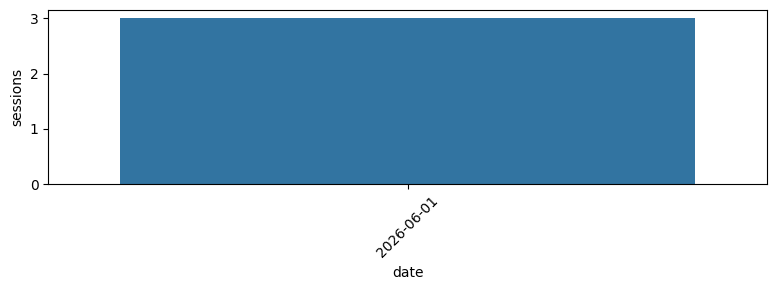

In [ ]:
# Load session history and plot daily counts

if HISTORY_JSON.exists():
    hist = pd.read_json(HISTORY_JSON)
elif HISTORY_DB.exists():
    conn = sqlite3.connect(str(HISTORY_DB))
    hist = pd.read_sql_query("SELECT * FROM sessions", conn)
    conn.close()
else:
    hist = pd.DataFrame()

if not hist.empty:
    hist["start_dt"] = pd.to_datetime(hist["start_ts"])
    hist["date"] = hist["start_dt"].dt.date
    daily = hist.groupby("date").size().reset_index(name="sessions")
    plt.figure(figsize=(8, 3))
    sns.barplot(data=daily, x="date", y="sessions")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("no history to plot")

In [ ]:
# Export session history to CSV; import JSON records with validation

def export_history_csv(path=Path("artifacts") / "keep_working_history.csv"):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    if HISTORY_JSON.exists():
        df = pd.read_json(HISTORY_JSON)
        df.to_csv(path, index=False)
        print("exported", path)
    else:
        print("no JSON history to export")


def import_history_json(path):
    data = json.loads(Path(path).read_text())
    required = ("task_name", "start_ts", "end_ts", "duration_s", "kind")
    for r in data:
        if not all(k in r for k in required):
            raise ValueError("invalid record — missing keys")
    existing = []
    if HISTORY_JSON.exists():
        existing = json.loads(HISTORY_JSON.read_text())
    HISTORY_JSON.write_text(json.dumps(existing + data, indent=2))
    print("imported", len(data), "records")

In [ ]:
# Break-scheduling rules engine

RULES = {"fatigue_threshold": 3, "extra_break_secs": 60}


def adjusted_break(consecutive_sessions, base_short=SHORT_BREAK):
    """Add extra break time after consecutive work sessions."""
    if consecutive_sessions >= RULES["fatigue_threshold"]:
        return base_short + RULES["extra_break_secs"]
    return base_short


print("rules engine ready")

rules engine ready


In [ ]:
# VS Code integration: settings UI, auto-run loop, systemd service export

VS_LOG = Path(".vscode") / "keep_working.log"
VS_LOG.parent.mkdir(parents=True, exist_ok=True)
VS_LOG.write_text("Keep Working log initialized\n")
print("wrote", VS_LOG)

if widgets:
    # Load saved config into widget defaults
    cfg = load_config()
    task_input = widgets.Text(value=cfg.get("task", "Unnamed"), description="Task:")
    work_input = widgets.IntText(value=int(cfg.get("work", 25 * 60)), description="Work(s):")
    short_input = widgets.IntText(value=int(cfg.get("short", 5 * 60)), description="Short(s):")
    long_input = widgets.IntText(value=int(cfg.get("long", 15 * 60)), description="Long(s):")
    cycles_input = widgets.IntText(value=int(cfg.get("cycles_per_long", 4)), description="Cycles/Long:")
    notify_chk = widgets.Checkbox(value=bool(cfg.get("notify", False)), description="Notify")
    sound_chk = widgets.Checkbox(value=bool(cfg.get("sound", False)), description="Sound")
    repeat_chk = widgets.Checkbox(value=bool(cfg.get("repeat", False)), description="Repeat")
    status_input = widgets.Text(
        value=cfg.get("status_file", str(Path("notebooks") / "keep_working_status.json")),
        description="StatusFile:",
    )
    run_btn = widgets.ToggleButton(value=False, description="Run")
    stop_btn = widgets.Button(description="Stop")
    export_btn = widgets.Button(description="Export systemd")

    hbox = widgets.VBox([
        task_input,
        widgets.HBox([work_input, short_input, long_input, cycles_input]),
        widgets.HBox([notify_chk, sound_chk, repeat_chk]),
        status_input,
        widgets.HBox([run_btn, stop_btn, export_btn]),
    ])
    display(hbox)

    def save_ui_config(_=None):
        save_config({
            "task": task_input.value,
            "work": int(work_input.value),
            "short": int(short_input.value),
            "long": int(long_input.value),
            "cycles_per_long": int(cycles_input.value),
            "notify": bool(notify_chk.value),
            "sound": bool(sound_chk.value),
            "repeat": bool(repeat_chk.value),
            "status_file": str(status_input.value),
        })

    # Persist settings whenever a widget value changes
    for w in (task_input, work_input, short_input, long_input, cycles_input,
              notify_chk, sound_chk, repeat_chk, status_input):
        try:
            w.observe(lambda _: save_ui_config(), names="value")
        except Exception:
            pass

    async def _runner():
        save_ui_config()
        async_pom.notify = notify_chk.value
        async_pom.sound = sound_chk.value
        async_pom.task_name = task_input.value
        cycle = 0
        while run_btn.value:
            cycle += 1
            async_pom.start(__async_loop__, seconds=work_input.value, kind="work", on_finish=_on_finish)
            while async_pom.is_running():
                await asyncio.sleep(0.5)
            if not run_btn.value:
                break
            if repeat_chk.value and cycles_input.value > 0 and (cycle % cycles_input.value) == 0:
                bsecs, bkind = long_input.value, "long_break"
            else:
                bsecs, bkind = short_input.value, "short_break"
            async_pom.start(__async_loop__, seconds=bsecs, kind=bkind, on_finish=_on_finish)
            while async_pom.is_running():
                await asyncio.sleep(0.5)
        print("runner exiting")

    def _export_systemd_clicked(_button):
        import shlex
        import getpass
        svc_path = Path(status_input.value).parent / "keep_working_from_notebook.service"
        try:
            python_exec = sys.executable
            workspace_dir = str(Path.cwd())
            launcher = str(Path(workspace_dir) / "notebooks" / "keep_working_launcher.py")
            args = [
                python_exec, launcher,
                "--task", task_input.value,
                "--work", str(work_input.value),
                "--short", str(short_input.value),
                "--long", str(long_input.value),
                "--cycles-per-long", str(cycles_input.value),
            ]
            if notify_chk.value:
                args.append("--notify")
            if sound_chk.value:
                args.append("--sound")
            if repeat_chk.value:
                args.append("--repeat")
            exec_cmd = " ".join(shlex.quote(a) for a in args)
            content = "\n".join([
                "[Unit]",
                "Description=Keep Working (notebook export)",
                "",
                "[Service]",
                "Type=simple",
                f"WorkingDirectory={workspace_dir}",
                f"ExecStart={exec_cmd}",
                "Restart=on-failure",
                f"User={getpass.getuser()}",
                "",
                "[Install]",
                "WantedBy=default.target",
                "",
            ])
            svc_path.write_text(content)
            save_ui_config()
            print("Wrote", svc_path)
        except Exception as e:
            print("Failed to export systemd:", e)

    def _on_run_change(change):
        if change["new"]:
            run_btn._task = __async_loop__.create_task(_runner())
        else:
            async_pom.stop()

    def _on_stop_clicked(_button):
        async_pom.stop()
        run_btn.value = False

    run_btn.observe(_on_run_change, names="value")
    stop_btn.on_click(_on_stop_clicked)
    export_btn.on_click(_export_systemd_clicked)

print("VS Code integration ready")

NameError: name 'Path' is not defined

In [ ]:
# Generate pytest tests for the launcher module

_tests_dir = Path("tests") / "keep_working"
_tests_dir.mkdir(parents=True, exist_ok=True)

_test_code = '''\
"""Tests for Keep Working Pomodoro timer and persistence."""
import json
import sys
from pathlib import Path

sys.path.insert(0, str(Path(__file__).resolve().parent.parent.parent))
from notebooks.keep_working_launcher import SessionRecord, append_json_record


def test_session_record_fields():
    rec = SessionRecord(task_name="t", start_ts="a", end_ts="b", duration_s=10, kind="work")
    assert rec.task_name == "t"
    assert rec.kind == "work"
    assert rec.duration_s == 10


def test_persistence_write(tmp_path):
    p = tmp_path / "hist.json"
    rec = SessionRecord(task_name="t", start_ts="a", end_ts="b", duration_s=10, kind="work")
    append_json_record(rec, path=p)
    assert p.exists()
    data = json.loads(p.read_text())
    assert len(data) == 1
    assert data[0]["task_name"] == "t"


def test_persistence_append(tmp_path):
    p = tmp_path / "hist.json"
    rec1 = SessionRecord(task_name="t1", start_ts="a", end_ts="b", duration_s=10, kind="work")
    rec2 = SessionRecord(task_name="t2", start_ts="c", end_ts="d", duration_s=20, kind="short_break")
    append_json_record(rec1, path=p)
    append_json_record(rec2, path=p)
    data = json.loads(p.read_text())
    assert len(data) == 2
    assert data[1]["task_name"] == "t2"


def test_session_record_kinds():
    for kind in ("work", "short_break", "long_break"):
        rec = SessionRecord(task_name="test", start_ts="s", end_ts="e", duration_s=1, kind=kind)
        assert rec.kind == kind
'''

(_tests_dir / "test_keep_working.py").write_text(_test_code)
print("wrote tests to", _tests_dir)
print("\nRun: .venv/bin/python -m pytest tests/keep_working -q")

wrote tests to /workspaces/Aria/tests/keep_working

Run: .venv/bin/python -m pytest tests/keep_working -q
